# qid 128 — what compression actually leaves the model to see

**Question:** *"What does the woman do before throwing the Coca-Cola can into the air?"*
**Gold:** A — *She dances with people* · **GT evidence:** `15:24–15:45` = **924–945 s** of a **3,296 s** video.

Previously (crop-only arm) the agent tiled `26→77→129→…→283 s` and never came within 600 s of the
evidence. Here it gets **both** tools, so it can do the intended coarse-to-fine thing: compress wide to
locate, then crop to confirm.

Two questions:
1. Does it actually reach for compression first?
2. **What survives compression?** — we map FlashVID's kept tokens back to pixel space and black out
   everything it discarded, so we see the model's literal field of view.

In [1]:
import json, os, numpy as np, matplotlib
matplotlib.use("Agg"); import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image
S=json.load(open("/local1/cfyang/hanklin/outputs/fast_agent/analysis/qid128/summary.json"))
print(S["question"]); [print("  ",o) for o in S["options"]]
print(f"\ngold={S['gold']}  evidence={S['evidence']}s  duration={S['duration']:.0f}s")
g=S["grid"]
print(f"\ncompression: {g['base']:,} visual tokens -> {g['kept']:,} kept (retention {g['retention']:.3f})")
print(f"grid: {g['t']} frame-groups x {g['tokens_per_group']} tokens/group  ({g['h']}x{g['w']} patches)")

What does the woman do before throwing the Coca-Cola can into the air?
   A. She dances with people
   B. She throws her shoe away
   C. She walks barefoot
   D. She fights with a police

gold=A  evidence=[924.0, 945.0]s  duration=3296s

compression: 51,072 visual tokens -> 5,714 kept (retention 0.100)
grid: 1064 frame-groups x 48 tokens/group  (12x16 patches)


## 1. It DID chain correctly — and then gave up

This is the first time we have observed the intended first move. Its own words:

In [2]:
a=S["agent"]
print("ROUND 0 (choosing the tool):")
print('  "I need to find the moment when the woman throws a Coca-Cola can into the air...')
print('   I\'ll start by using `compress_video` to scan the entire video to locate this scene."')
print(f"  -> {a['tool_calls']}")
print("\nROUND 1 (after seeing the compressed video):")
print('  "I have reviewed the entire video using `compress_video` and have NOT FOUND any scene')
print('   where a woman throws a Coca-Cola can into the air. The video contains various animated')
print('   scenes... but there is no depiction of a woman performing that action."')
print("\nFINALIZER:  <answer>None of the above</answer>")
print(f"\n  pred={a['pred']}   gold={S['gold']}   correct={a['correct']}")
print("\nThe strategy was right. It compressed wide FIRST -- exactly the coarse-to-fine opening.")
print("It then concluded the scene does not exist, instead of narrowing. The chain broke at step 2.")

ROUND 0 (choosing the tool):
  "I need to find the moment when the woman throws a Coca-Cola can into the air...
   I'll start by using `compress_video` to scan the entire video to locate this scene."
  -> [['compress_video', 0, 3296]]

ROUND 1 (after seeing the compressed video):
  "I have reviewed the entire video using `compress_video` and have NOT FOUND any scene
   where a woman throws a Coca-Cola can into the air. The video contains various animated
   scenes... but there is no depiction of a woman performing that action."

FINALIZER:  <answer>None of the above</answer>

  pred=None   gold=A   correct=False

The strategy was right. It compressed wide FIRST -- exactly the coarse-to-fine opening.
It then concluded the scene does not exist, instead of narrowing. The chain broke at step 2.


## 2. Why it "didn't find" the scene — it never saw it

Each surviving token maps back to an exact patch of pixels:

```
token i → group  gt = i // tokens_per_group        (covers raw frames 2·gt, 2·gt+1)
          row    gh = (i % tokens_per_group) // grid_w
          col    gw = (i % tokens_per_group) %  grid_w
        → pixels [gh·32 : gh·32+32,  gw·32 : gw·32+32]
```

Below, **left = the real frame, right = only the patches the model actually receives** (everything
discarded is black). These are frames from *inside* the ground-truth evidence window.

**t = 927s — inside GT evidence — kept **6/48** tokens (12% of the frame)

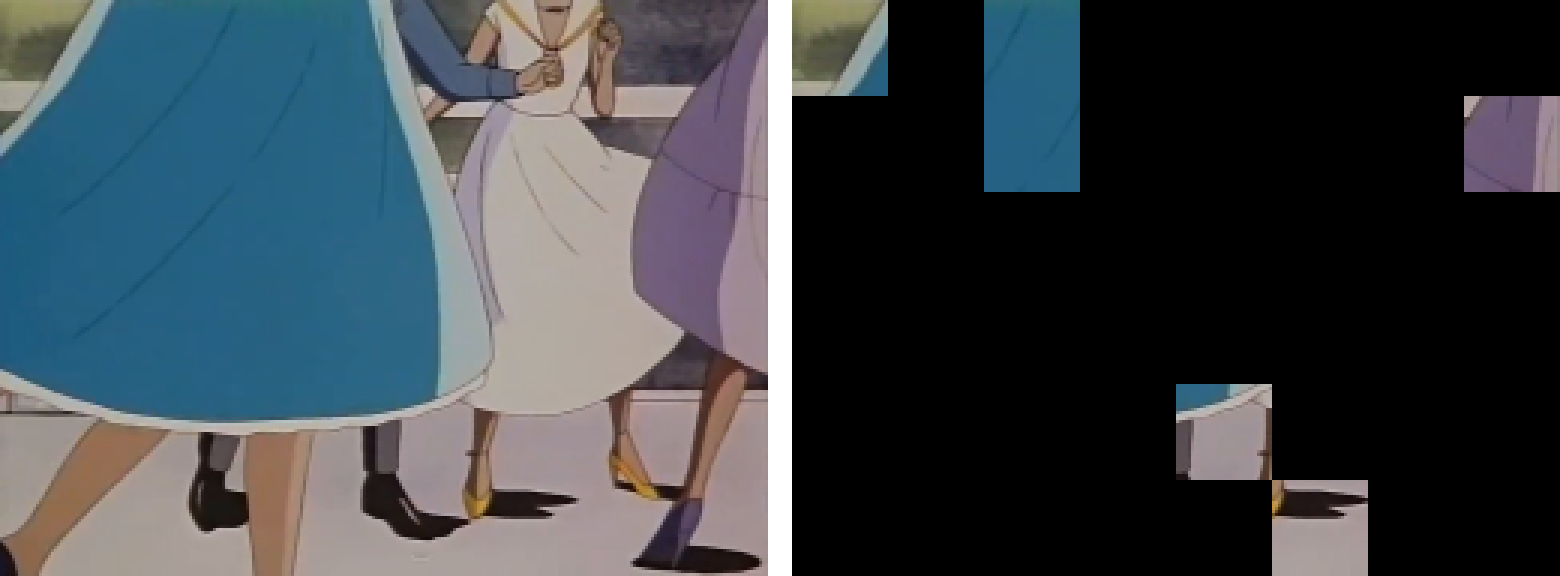

**t = 930s — inside GT evidence — kept **6/48** tokens (12% of the frame)

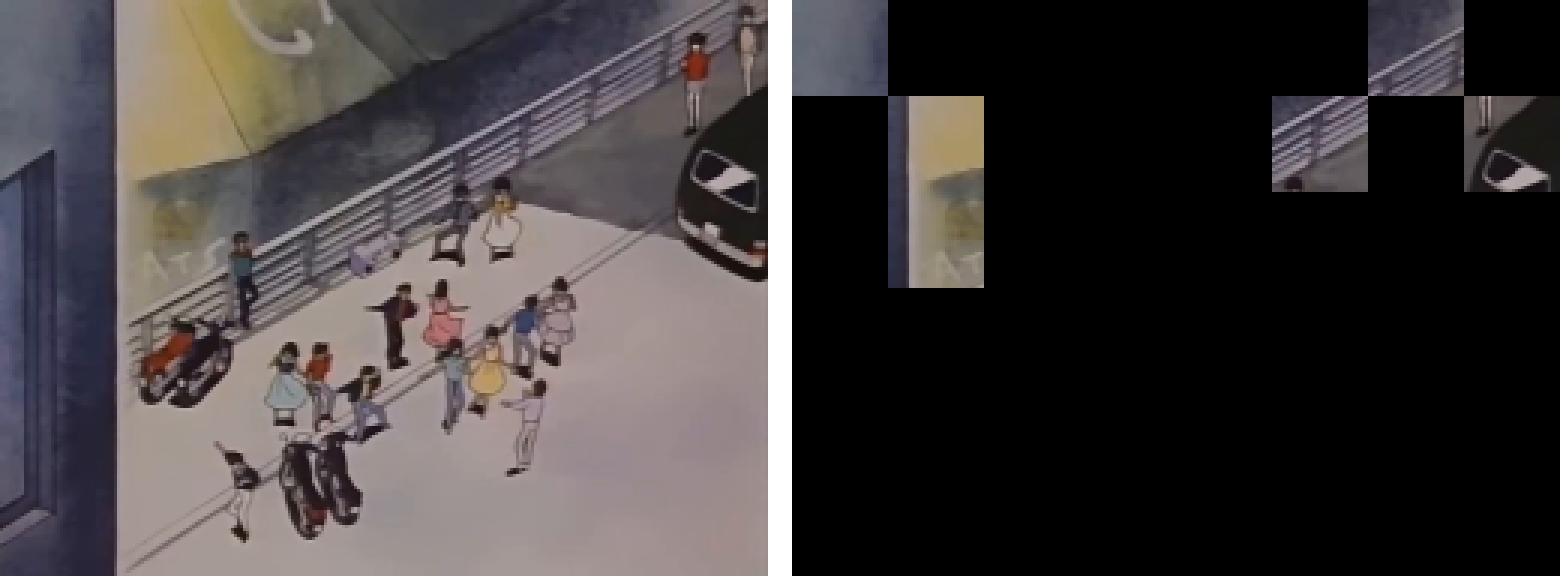

**t = 933s — inside GT evidence — kept **5/48** tokens (10% of the frame)

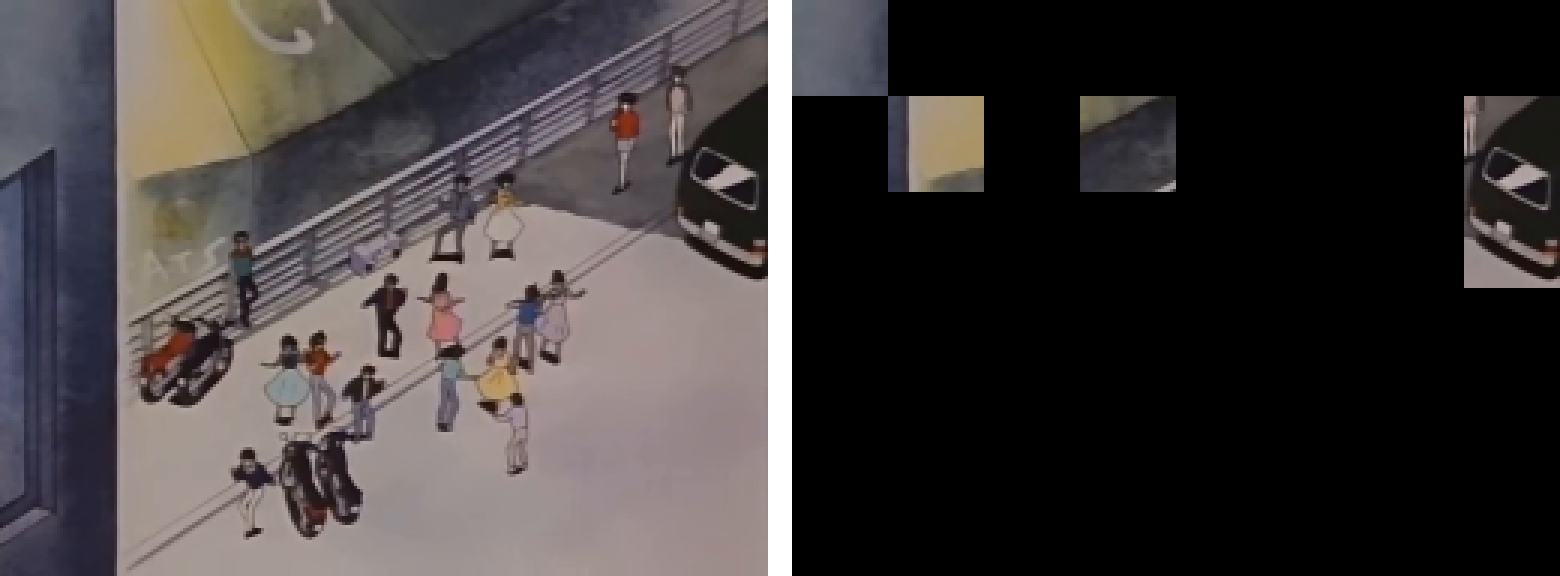

In [3]:
for r in S["renders"]:
    if "INSIDE" in r["tag"]:
        display(Markdown(f"**t = {r['time']:.0f}s — inside GT evidence — kept **{r['kept']}/{r['of']}** tokens ({100*r['kept']/r['of']:.0f}% of the frame)"))
        display(Image(filename=r["png"]))

**That is the answer.** The gold answer is *"she dances with people"* — and the left frame plainly
shows exactly that: swirling skirts, legs mid-step, several dancers. What the model receives is **6 of
48 patches**: a fragment of blue skirt, a sliver of purple, one shoe. The dance is unrecoverable.

So when the model said *"I have reviewed the entire video and have not found any scene where a woman
throws a Coca-Cola can"* — **it was telling the truth.** It was not lazy or overconfident. The evidence
was deleted before it ever reached the language model.

## 3. The budget is spread perfectly uniformly — compression carries no localization signal

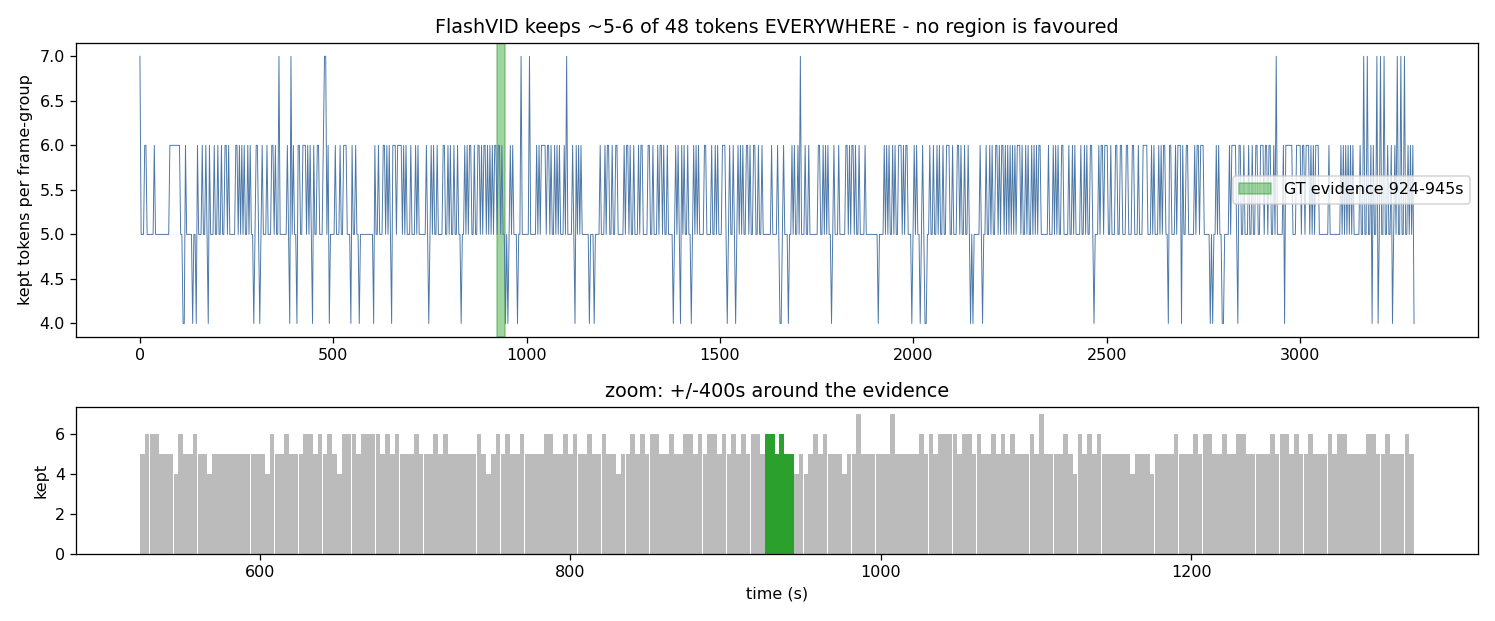

kept-token share INSIDE evidence : 0.58%
uniform expectation              : 0.56%
CONCENTRATION RATIO              : 1.03x   (1.0 = no preference)
frame-groups with ZERO kept      : 0/1064
median kept/group                : 5 of 48


In [4]:
kpg=np.array(S["kept_per_group"]); gt_=np.array(S["group_time"]); ev=S["evidence"]
fig,ax=plt.subplots(2,1,figsize=(13,5.4),gridspec_kw={"height_ratios":[2,1]})
ax[0].plot(gt_,kpg,lw=.6,color="#4C78A8")
ax[0].axvspan(ev[0],ev[1],color="#2CA02C",alpha=.45,label="GT evidence 924-945s")
ax[0].set_ylabel("kept tokens per frame-group"); ax[0].legend()
ax[0].set_title("FlashVID keeps ~5-6 of 48 tokens EVERYWHERE - no region is favoured")
m=(gt_>=ev[0]-400)&(gt_<=ev[1]+400)
ax[1].bar(gt_[m],kpg[m],width=3,color=["#2CA02C" if ev[0]<=x<=ev[1] else "#bbb" for x in gt_[m]])
ax[1].set_xlabel("time (s)"); ax[1].set_ylabel("kept"); ax[1].set_title("zoom: +/-400s around the evidence")
plt.tight_layout(); plt.savefig("/tmp/q128.png",dpi=115); plt.close(); display(Image("/tmp/q128.png"))
print(f"kept-token share INSIDE evidence : {100*S['evidence_share']:.2f}%")
print(f"uniform expectation              : {100*S['uniform_share']:.2f}%")
print(f"CONCENTRATION RATIO              : {S['evidence_share']/S['uniform_share']:.2f}x   (1.0 = no preference)")
print(f"frame-groups with ZERO kept      : {S['zero_groups']}/{S['grid']['t']}")
print(f"median kept/group                : {np.median(kpg):.0f} of {S['grid']['tokens_per_group']}")

**Concentration ratio 1.03× means FlashVID gave the evidence window no more budget than any other
moment.** It is query-blind by construction — CLS-attention saliency knows nothing about "Coca-Cola" or
"dancing". It does not drop *regions*; it thins *every* frame to ~11% of its patches, uniformly.

That is the crux: **compression at whole-video scale trades away exactly the thing the coarse step is
supposed to provide.** A coverage tool is only useful if it preserves enough signal to say *"look near
here"*. This one returns 1,064 uniformly-shredded frames, from which no region can be nominated.

## 4. What this means for tools and policy

**Compress→crop chaining cannot work with a query-blind compressor at this budget.** The archive
recorded that the model "never chains compress→crop" and read it as a policy failure. This case shows
it is partly a *tool* failure: step 1 destroys the target, so step 2 has nothing to aim at. Here the
model performed the chain's first move correctly and was punished for it — it would have scored better
never touching the tool.

**Three concrete implications:**

1. **A coverage tool must be query-aware.** SemVID (already integrated, `FA_COMPRESSOR=semvid`) selects
   tokens conditioned on the question and measured **1.22× concentration** in the evidence span on an
   earlier probe versus FlashVID's 0.96×. Re-running this exact case under SemVID is the natural test —
   if concentration rises materially, compress→crop becomes viable; if not, whole-video compression
   should be dropped as a localization primitive.

2. **Retention should scale with span, not be fixed.** 0.1 over 3,296 s leaves ~6 patches per frame.
   The same retention over a 300 s window would leave the same per-frame density — the problem is the
   *absolute* per-frame budget, which should have a floor below which the tool refuses or narrows.

3. **The refusal was correct behaviour on bad input.** Do not train this away. Under RL with an
   outcome-only reward, this trajectory is penalised — teaching the model to *stop* using the coverage
   tool rather than to use it better. The reward needs to credit the correct opening move, or shaping
   will select against coarse-to-fine entirely.

**And the deeper point for the chapter's thesis:** the value of "compression as an action" depends
entirely on whether the compressor preserves query-relevant signal. Measured at 1.03×, FlashVID
provides none — which is consistent with every null result on compression in this project's history,
and finally shows the mechanism rather than inferring it from accuracy.